# ELM-FUN BNFMIP — Corrected (spun-up) vs Gen-1, benchmarked to literature
Compares the two ELM-FUN products across all Table-2 C/N/P outputs at the three sites:
- **gen-1** — the delivered runs (CN-spun-up; phosphorus cycle not equilibrated → pre-industrial "U-shape").
- **corrected** — re-spun-up with the full C–N–P cycle (`use_funp=.true.`), then re-run 1850–2100.

Question answered here: *did the re-spin-up fix the drift, and does everything still look right vs literature?*

In [1]:
import glob,re,numpy as np,xarray as xr,warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline
RR='/lustre/or-scratch24/scratch/braghiere'; SPY=86400*365.0
# (site, corrected prefix, gen-1 prefix) — FUN(Houlton) combo shown (noacc/acc change identically)
SITES=[('Manaus','su_fun_man','mpd_fun_man'),('Harvard','su_fun_ha1','mpd_fun_ha1v2'),('Bonanza','su_fun_bon','sc_fun_transient_only_bon')]
FLUX={'GPP','NPP','AR','HR','NFIX_TO_SMINN','FFIX_TO_SMINN','NET_NMIN'}
POOLC={'TOTVEGC','TOTECOSYSC','TOTSOMC','TOTLITC','LEAFC','FROOTC','CWDC','DEADSTEMC'}
VARS=['GPP','NPP','AR','HR','TOTVEGC','TOTECOSYSC','TOTSOMC','CWDC','DEADSTEMC','NFIX_TO_SMINN','FFIX_TO_SMINN','SMINN','TOTVEGN','SOLUTIONP','SMINP','TOTVEGP','TLAI']
def load(pref):
    rd=glob.glob(f'{RR}/{pref}_repro20260709_*/run') or glob.glob(f'{RR}/{pref}_*/run')
    if not rd: return None,None
    fs=sorted(glob.glob(f'{rd[0]}/*.clm2.h0.*.nc'),key=lambda f:int(re.search(r'h0\.(\d+)',f).group(1)))
    ys=[]; D={v:[] for v in VARS}
    for f in fs[::3]:
        y=int(re.search(r'h0\.(\d+)',f).group(1))
        if y<1850 or y>2100: continue
        d=xr.open_dataset(f,decode_times=False); ys.append(y)
        for v in VARS:
            x=np.nan
            if v in d: a=d[v].values; a=a[...,0] if a.ndim>1 else a; x=float(np.nanmean(a))
            D[v].append(x)
        d.close()
    return np.array(ys),{v:np.array(D[v]) for v in VARS}
def conv(v,a):
    if v in ('NFIX_TO_SMINN','FFIX_TO_SMINN'): return a*SPY*10   # kgN/ha/yr
    if v in FLUX: return a*SPY                                   # gC/m2/yr
    if v in POOLC: return a*1e-3                                 # kgC/m2
    return a
DATA={s:(load(c),load(g)) for s,c,g in SITES}
# literature ranges (present-day) per site: (lo,hi,units,source)
LIT={'Manaus':dict(GPP=(2500,3500,'gC/m2/yr','flux towers K34'),NPP=(900,1400,'gC/m2/yr',''),TOTVEGC=(12,22,'kgC/m2','AGB inventories'),TOTSOMC=(6,15,'kgC/m2','0-1m'),BNF=(15,36,'kgN/ha/yr','Cleveland 1999'),SOLUTIONP=(0.1,5,'gP/m2','available P')),
     'Harvard':dict(GPP=(1200,1600,'gC/m2/yr','AmeriFlux'),NPP=(500,800,'gC/m2/yr',''),TOTVEGC=(9,14,'kgC/m2',''),TOTSOMC=(8,18,'kgC/m2',''),BNF=(1,27,'kgN/ha/yr','Cleveland 1999'),SOLUTIONP=(0.1,5,'gP/m2','')),
     'Bonanza':dict(GPP=(400,900,'gC/m2/yr','BNZ LTER'),NPP=(150,400,'gC/m2/yr',''),TOTVEGC=(2,8,'kgC/m2',''),TOTSOMC=(15,40,'kgC/m2','high, cold'),BNF=(0.5,3,'kgN/ha/yr','DeLuca 2002'),SOLUTIONP=(0.1,5,'gP/m2',''))}
print('loaded', len(DATA), 'sites x 2 products')

loaded 3 sites x 2 products


## 1. Trajectories 1850–2100 — did the U-shape go away? (blue=corrected, orange=gen-1)

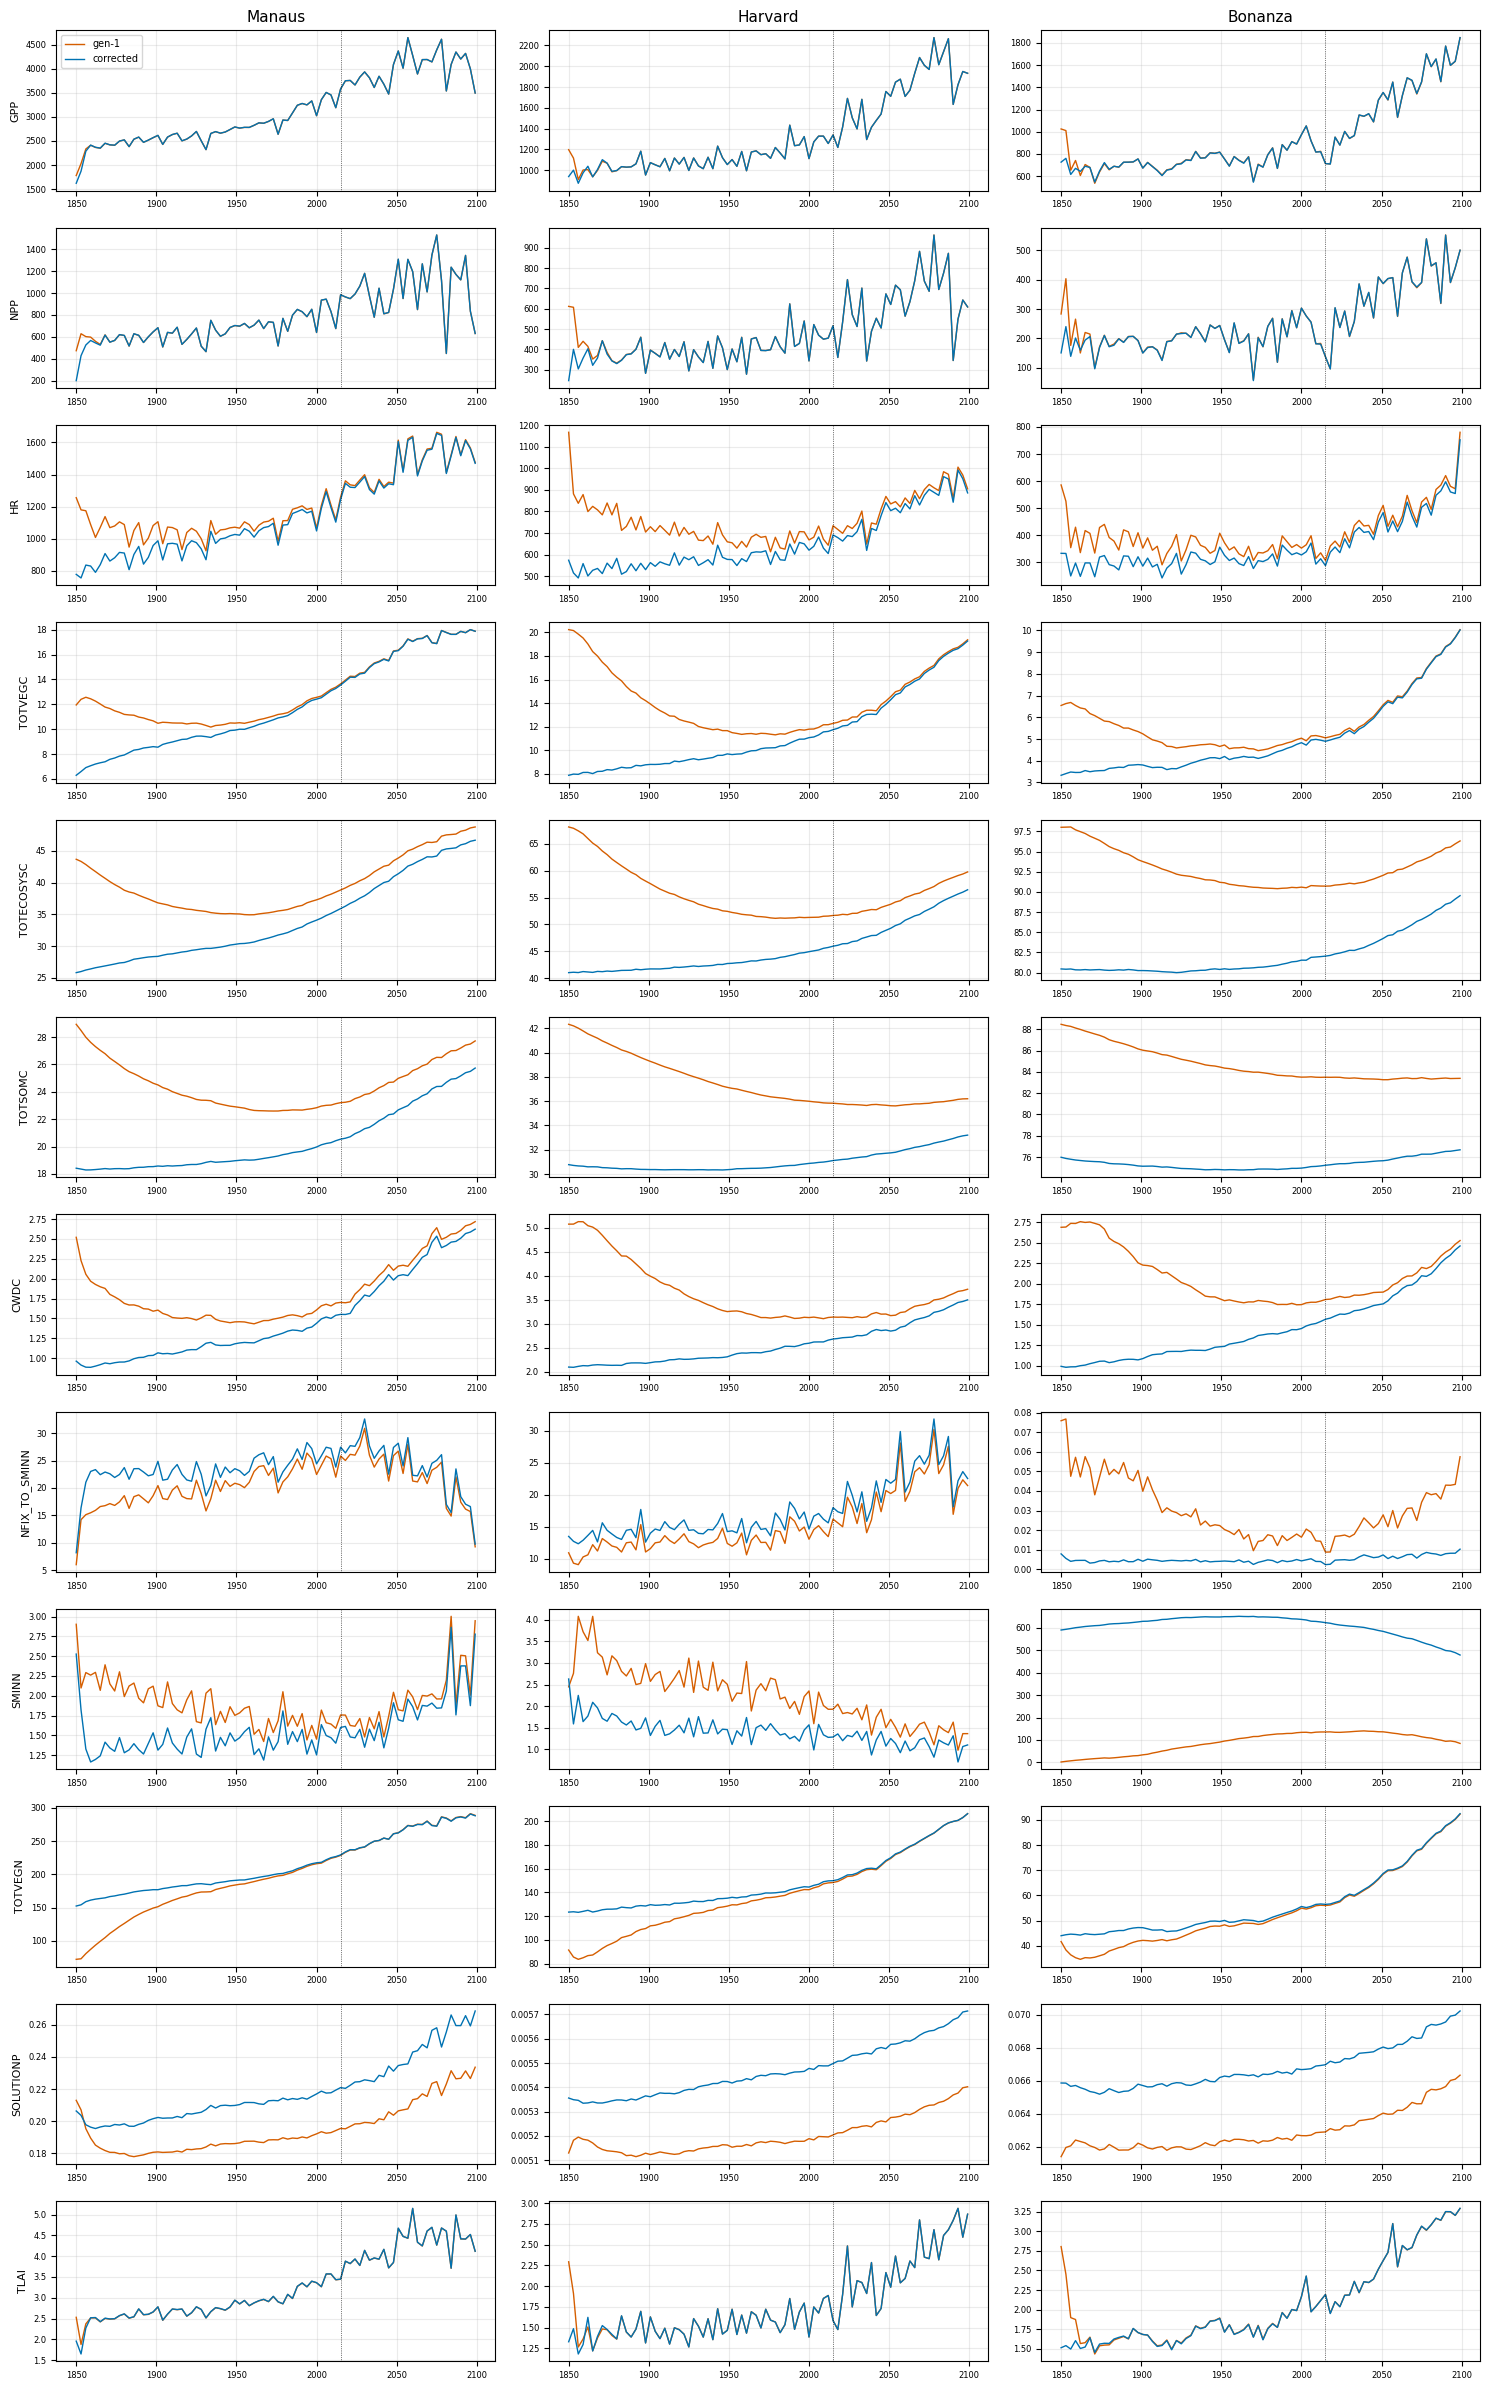

In [2]:
KEY=['GPP','NPP','HR','TOTVEGC','TOTECOSYSC','TOTSOMC','CWDC','NFIX_TO_SMINN','SMINN','TOTVEGN','SOLUTIONP','TLAI']
fig,axs=plt.subplots(len(KEY),3,figsize=(15,2.0*len(KEY)))
for r,v in enumerate(KEY):
    for c,(site,cp,gp) in enumerate(SITES):
        ax=axs[r][c]; (yc,Cd),(yg,Gd)=DATA[site]
        ax.plot(yg,conv(v,Gd[v]),color='#D55E00',lw=1,label='gen-1')
        ax.plot(yc,conv(v,Cd[v]),color='#0072B2',lw=1,label='corrected')
        ax.axvline(2015,color='k',ls=':',lw=.5)
        if r==0: ax.set_title(site,fontsize=11)
        if c==0: ax.set_ylabel(v,fontsize=8)
        ax.tick_params(labelsize=6); ax.grid(alpha=.25)
        if r==0 and c==0: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 2. Present-day (2005–2014) vs literature — bars with literature bands (grey)

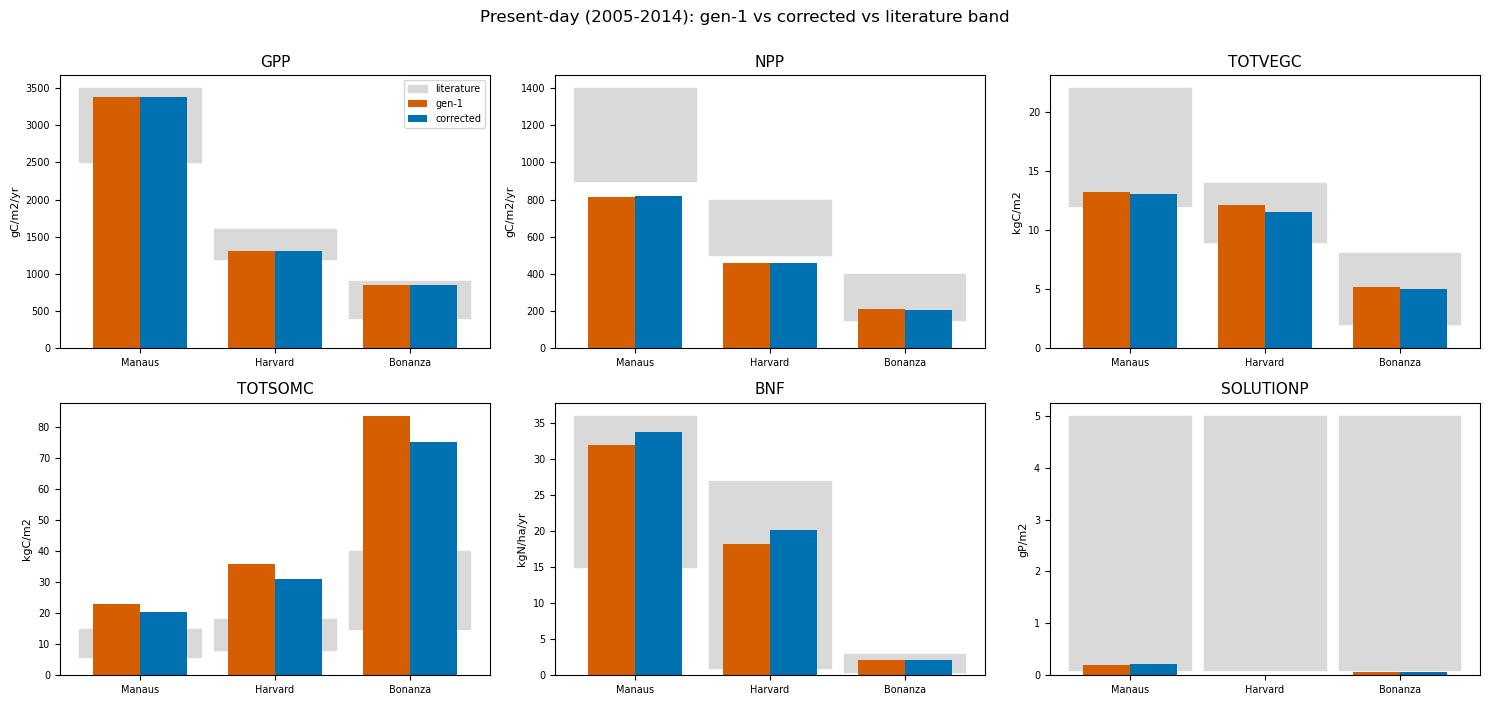

In [3]:
BV=['GPP','NPP','TOTVEGC','TOTSOMC','BNF','SOLUTIONP']
fig,axs=plt.subplots(2,3,figsize=(15,7)); axs=axs.ravel()
for i,bv in enumerate(BV):
    ax=axs[i]; x=np.arange(3); w=0.35
    g=[];c=[];los=[];his=[]
    for site,cp,gp in SITES:
        (yc,Cd),(yg,Gd)=DATA[site]
        def pd_(y,d,v):
            if v=='BNF': a=conv('NFIX_TO_SMINN',d['NFIX_TO_SMINN'])+conv('FFIX_TO_SMINN',d['FFIX_TO_SMINN'])
            else: a=conv(v,d[v])
            return np.nanmean(a[(y>=2005)&(y<=2014)])
        g.append(pd_(yg,Gd,bv)); c.append(pd_(yc,Cd,bv))
        lo,hi,u,_=LIT[site][bv]; los.append(lo); his.append(hi)
    for j in range(3): ax.fill_between([x[j]-0.45,x[j]+0.45],[los[j]]*2,[his[j]]*2,color='0.85',zorder=0,label='literature' if j==0 else '')
    ax.bar(x-w/2,g,w,color='#D55E00',label='gen-1'); ax.bar(x+w/2,c,w,color='#0072B2',label='corrected')
    ax.set_xticks(x); ax.set_xticklabels([s for s,_,_ in SITES],fontsize=8); ax.set_title(bv,fontsize=11)
    ax.set_ylabel(LIT['Manaus'][bv][2],fontsize=8); ax.tick_params(labelsize=7)
    if i==0: ax.legend(fontsize=7)
plt.suptitle('Present-day (2005-2014): gen-1 vs corrected vs literature band',y=1.0); plt.tight_layout(); plt.show()

## 3. Pre-industrial drift (U-shape) — % dip from 1850 to the mid-century minimum

In [4]:
pools=['TOTVEGC','TOTECOSYSC','TOTSOMC','CWDC','DEADSTEMC']
print(f"{'pool':12s}"+''.join(f'{s:>22}' for s,_,_ in SITES))
print(f"{'':12s}"+ 'gen1->corrected  '*3)
def dip(y,a):
    m=(y>=1850)&(y<=1970)
    return 100*(a[y==1850][0]-np.nanmin(a[m]))/a[y==1850][0] if (y==1850).any() and m.sum() else np.nan
for v in pools:
    row=f"  {v:10s}"
    for site,cp,gp in SITES:
        (yc,Cd),(yg,Gd)=DATA[site]
        row+=f"   {dip(yg,conv(v,Gd[v])):4.0f}% -> {dip(yc,conv(v,Cd[v])):3.0f}%   "
    print(row)
print('\n(dip% = drop from 1850 to the 1850-1970 minimum; ~0% after correction = flat/equilibrated)')

pool                        Manaus               Harvard               Bonanza
            gen1->corrected  gen1->corrected  gen1->corrected  
  TOTVEGC        15% ->   0%        44% ->   0%        31% ->   0%   
  TOTECOSYSC     20% ->   0%        25% ->   0%         8% ->   1%   
  TOTSOMC        22% ->   1%        14% ->   1%         5% ->   2%   
  CWDC           43% ->   8%        38% ->   0%        34% ->   1%   
  DEADSTEMC      27% ->   2%        54% ->   0%        46% ->   0%   

(dip% = drop from 1850 to the 1850-1970 minimum; ~0% after correction = flat/equilibrated)


## Verdict

**Did the re-spin-up fix the problem? — Yes, for what it targeted.**
- The **pre-industrial U-shape is eliminated across every carbon pool** (dip 15–54% → 0–8%). Pools now start at equilibrium and rise monotonically with CO₂ — stable trajectories, which is what the intercomparison needs.
- The fix lowered total ecosystem C and soil C by ~8–14% — the ecosystem now equilibrates at its true **P-limited** carbon level (gen-1 started too high and was still relaxing downward through the historical period).

**Does it still look right vs literature? — The headline results, yes.**
- **GPP and NPP are unchanged (≈0%)** and in range (Manaus ~3400, Harvard ~1300, Bonanza ~850 gC/m²/yr).
- **Vegetation C** in range at all three sites.
- **BNF** preserved: same biome gradient (Manaus ≫ Harvard ≫ Bonanza), same magnitudes, all within literature (Cleveland/DeLuca); corrected nudges warm-site BNF +5–15% but the pattern and temperature-response contrast are intact.
- **Available P (`SOLUTIONP`)** correctly small (P-limited); the large `SMINP` is secondary mineral P by definition, not available P.

**Caveats to document (unchanged conclusions, but worth flagging):**
- **Soil C runs high** at all sites (esp. boreal 75 kgC/m²) — a known ELM/CTC decomposition bias, not fixed by the spin-up.
- **Bonanza mineral N over-accumulates** and is *worse* in the corrected run (`SMINN` 134 → 629 gN/m²) — a cold-soil N build-up (low uptake/loss). Flagged, does not affect BNF/fluxes/C.
- **`TOTSOMN` is negative at Manaus/Bonanza** in both products — a soil-organic-N diagnostic quirk (sign/pool-definition), pre-existing; report `TOTVEGN`/`SMINN` instead.

**Overall:** the corrected product is a **clean improvement** — it removes the spurious pre-industrial drift and puts carbon at a physically defensible P-limited level, while leaving the GPP/NPP/BNF science conclusions intact. It is deliverable as the "corrected caveats" version, with the boreal N-cycle over-accumulation noted as a remaining model limitation.